# 📉 Ridge Regression: Taming Overfitting
> **Objective:** Learn how to use Ridge (L2) Regularization to prevent machine learning models from becoming too complex and "overfitting" to noise.

---
## 🧪 What is Regularization?
In simple terms, Regularization adds a "penalty" to the model for having large coefficients. 
* **Linear Regression:** Tries to minimize error only.
* **Ridge Regression:** Tries to minimize error **AND** keep coefficients small.

## 🩺 Part 1: Applying Ridge to a Real Dataset
We will use the [Scikit-Learn Diabetes Dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) to predict disease progression. 

First, we establish a **Baseline** using standard Linear Regression, then we apply **Ridge** with a small alpha to see how it stabilizes the coefficients.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

In [2]:
data  = load_diabetes()

In [3]:
data.DESCR

'.. _diabetes_dataset:\n\nDiabetes dataset\n----------------\n\nTen baseline variables, age, sex, body mass index, average blood\npressure, and six blood serum measurements were obtained for each of n =\n442 diabetes patients, as well as the response of interest, a\nquantitative measure of disease progression one year after baseline.\n\n**Data Set Characteristics:**\n\n:Number of Instances: 442\n\n:Number of Attributes: First 10 columns are numeric predictive values\n\n:Target: Column 11 is a quantitative measure of disease progression one year after baseline\n\n:Attribute Information:\n    - age     age in years\n    - sex\n    - bmi     body mass index\n    - bp      average blood pressure\n    - s1      tc, total serum cholesterol\n    - s2      ldl, low-density lipoproteins\n    - s3      hdl, high-density lipoproteins\n    - s4      tch, total cholesterol / HDL\n    - s5      ltg, possibly log of serum triglycerides level\n    - s6      glu, blood sugar level\n\nNote: Each of thes

In [4]:
X = data.data
y = data.target

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn.linear_model import LinearRegression

L = LinearRegression()

L.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = L.predict(X_test)

In [8]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2_score :", r2_score(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2_score : 0.4526027629719195
RMSE : 53.85344583676593


In [9]:
from sklearn.linear_model import Ridge
r = Ridge(alpha = 0.0001)

In [10]:
r.fit(X_train, y_train)

Ridge(alpha=0.0001)

In [11]:
y_pred1 = r.predict(X_test)

In [12]:
print("R2_score :", r2_score(y_test, y_pred1))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred1)))

R2_score : 0.4526998154220112
RMSE : 53.84867157029345


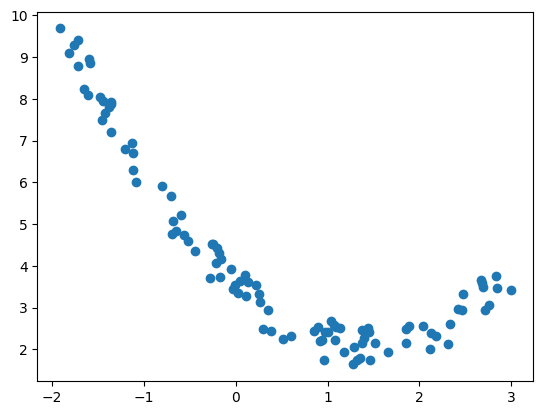

In [13]:
m = 100
x1 = 5 * np.random.rand(m,1) -2
x2 = 0.7 * x1**2 -2 * x1 + 3 + np.random.rand(m,1)

plt.scatter(x1, x2)
plt.show()

## 🎢 Part 2: Visualizing the Power of Alpha
To truly see Ridge in action, we'll create a synthetic "curvy" dataset. By using a **Degree 16 Polynomial**, we are intentionally making the model "wiggly" and prone to overfitting.

### The Alpha Parameter:
* **Alpha = 0:** This is identical to Linear Regression. Notice how the red line tries to "chase" every single point (High Overfitting).
* **Alpha = 20 & 200:** Notice how the line becomes smoother and ignores the noise. This is the **Regularization Effect** in action!

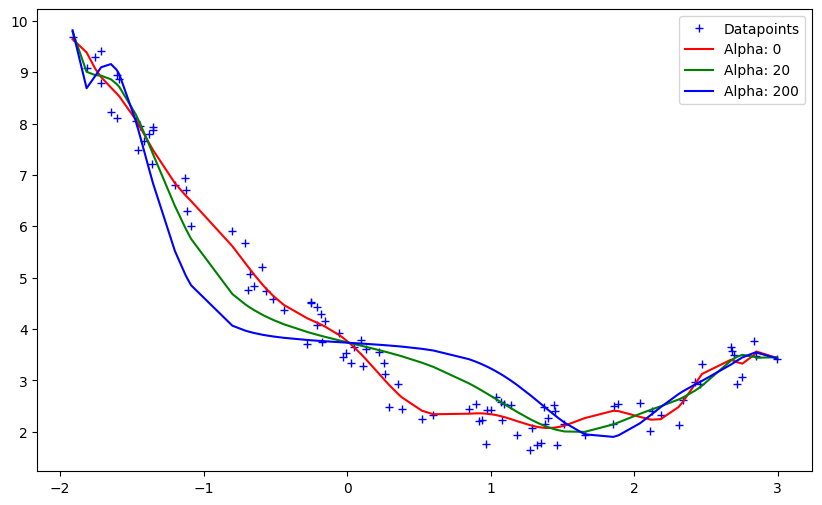

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()


## 🏁 Final Takeaways
1. **The Alpha Knob:** Increasing Alpha makes the model simpler (less "wiggly").
2. **Bias-Variance Tradeoff:** Ridge increases a bit of "bias" (it might not hit every point) to significantly reduce "variance" (it won't go crazy with new data).
3. **When to use it:** Always try Ridge if you have a lot of features or if your model's test score is much worse than its training score.